In [82]:
import argparse
import os
import random


import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set_style('darkgrid')
import torch
if torch.cuda.is_available():
    # For faster
    torch.set_float32_matmul_precision('high')   
from tqdm.auto import tqdm

from data.custom_datasets import SortDataset
from models.ctm_sort import ContinuousThoughtMachineSORT
from tasks.image_classification.plotting import plot_neural_dynamics, make_classification_gif
from utils.housekeeping import set_seed, zip_python_code
from utils.losses import sort_loss
from tasks.sort.utils import compute_ctc_accuracy, decode_predictions
from utils.schedulers import WarmupCosineAnnealingLR, WarmupMultiStepLR, warmup

import torchvision
torchvision.disable_beta_transforms_warning()

from autoclip.torch import QuantileClip

In [83]:
%matplotlib inline


In [84]:
prediction_reshaper = [-1]  # Problem specific

In [85]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [86]:
n_to_sort = 30

In [87]:
models = [
    (f'ctm_base_{n_to_sort}', False),
    (f'ctm_adaptive_eviction_{n_to_sort}', True),
]

In [88]:
def get_model(adaptive_eviction=False):
    model = ContinuousThoughtMachineSORT(
        iterations=50,
        d_model=512,
        d_input=n_to_sort,  
        heads=4,
        n_synch_out=32,
        n_synch_action=32,
        synapse_depth=4,
        memory_length=25,  
        deep_nlms=True,
        memory_hidden_dims=4,  
        do_layernorm_nlm=False,  
        backbone_type='none',
        positional_embedding_type='none',
        out_dims=n_to_sort+1,
        prediction_reshaper=prediction_reshaper,
        dropout=0.0,      
        dropout_nlm=None,    
        neuron_select_type='random-pairing',
        n_random_pairing_self=0,
        adaptive_eviction=adaptive_eviction,
    ).to(device)
    return model

In [89]:
train_accuracies_lists = []
test_accuracies_lists = []

train_accuracies_full_lists = []
test_accuracies_full_lists = []

train_loss_lists = []
test_loss_lists = []

iters_lists = []

In [90]:
for dir, adap in models:
    model = get_model(adaptive_eviction=adap)
    model.eval()
    print(f'Reloading from: logs/sort/{dir}/checkpoint.pt')
    checkpoint = torch.load(f'logs/sort/{dir}/checkpoint.pt', map_location=device, weights_only=False)
    model.load_state_dict(checkpoint['model_state_dict'], strict=True)
    print(f'Total params: {sum(p.numel() for p in model.parameters())}')
    print('Reloading optimizer etc.')
    # optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    # scaler.load_state_dict(checkpoint['scaler_state_dict'])
    start_iter = checkpoint['iteration']
    train_losses = checkpoint['train_losses']
    train_accuracies_full_list = checkpoint['train_accuracies_full_list']
    train_accuracies = checkpoint['train_accuracies']
    test_losses = checkpoint['test_losses']
    test_accuracies_full_list = checkpoint['test_accuracies_full_list']
    test_accuracies = checkpoint['test_accuracies']
    iters = checkpoint['iters']

    train_accuracies_lists.append(train_accuracies)
    test_accuracies_lists.append(test_accuracies)

    train_accuracies_full_lists.append(train_accuracies_full_list)
    test_accuracies_full_lists.append(test_accuracies_full_list)

    train_loss_lists.append(train_losses)
    test_loss_lists.append(test_losses)

    iters_lists.append(iters)

Using neuron select type: random-pairing
Synch representation size action: 0
Synch representation size out: 32
Reloading from: logs/sort/ctm_base_30/checkpoint.pt
Total params: 897197
Reloading optimizer etc.
Using neuron select type: random-pairing
Synch representation size action: 0
Synch representation size out: 32
Reloading from: logs/sort/ctm_adaptive_eviction_30/checkpoint.pt
Total params: 999766
Reloading optimizer etc.


In [91]:
iters

[0,
 1000,
 2000,
 3000,
 4000,
 5000,
 6000,
 7000,
 8000,
 9000,
 10000,
 11000,
 12000,
 13000,
 14000,
 15000,
 16000,
 17000,
 18000,
 19000,
 20000,
 21000,
 22000,
 23000,
 24000,
 25000,
 26000,
 27000,
 28000,
 29000,
 30000,
 31000,
 32000,
 33000,
 34000,
 35000,
 36000,
 37000,
 38000,
 39000,
 40000,
 41000,
 42000,
 43000,
 44000,
 45000,
 46000,
 47000,
 48000,
 49000,
 50000]

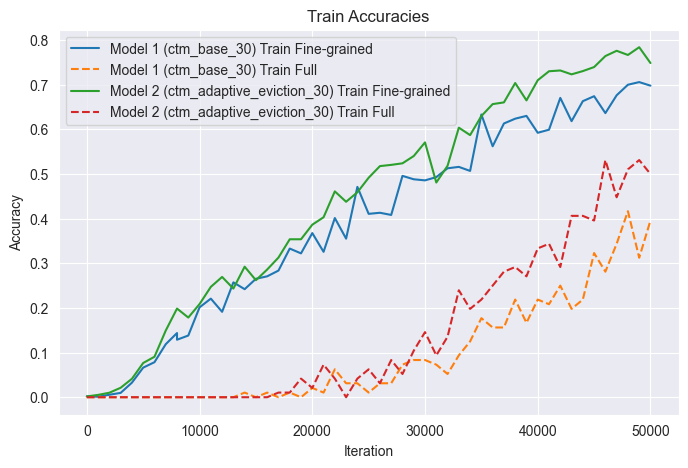

In [92]:
# Plot train and test accuracies
plt.figure(figsize=(8, 5))

for i, (iters, train_accuracies, train_full_accuracies) in enumerate(zip(iters_lists, train_accuracies_lists, train_accuracies_full_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    plt.plot(iters, train_accuracies, label=f'{label} Train Fine-grained')
    plt.plot(iters, train_full_accuracies, label=f'{label} Train Full', linestyle='--')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Train Accuracies')
plt.legend()
# plt.show()

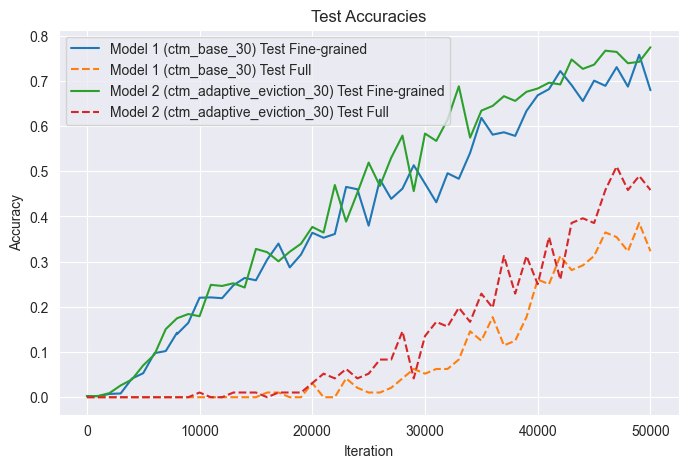

In [93]:
# Plot train and test accuracies
plt.figure(figsize=(8, 5))

for i, (iters, test_accuracies, test_full_accuracies) in enumerate(zip(iters_lists, test_accuracies_lists, test_accuracies_full_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    plt.plot(iters, test_accuracies, label=f'{label} Test Fine-grained')
    plt.plot(iters, test_full_accuracies, label=f'{label} Test Full', linestyle='--')

plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Test Accuracies')
plt.legend()

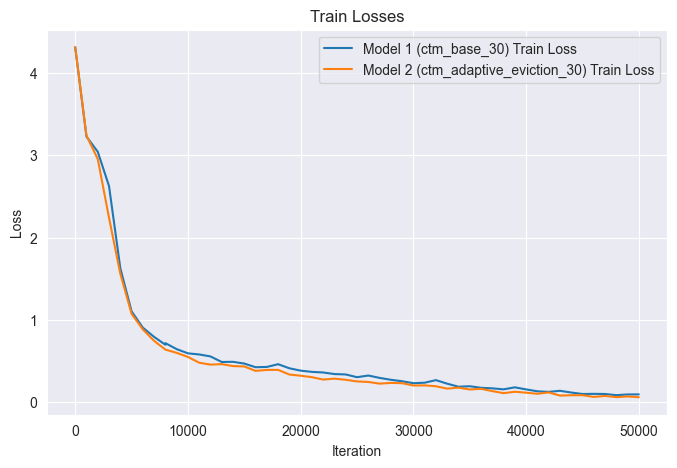

In [94]:
plt.figure(figsize=(8, 5))

for i, (iters, train_losses) in enumerate(zip(iters_lists, train_loss_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    plt.plot(iters, train_losses, label=f'{label} Train Loss')

# Zoom to last 5000 iterations
# plt.xlim(iters[-8], iters[-1])
# plt.ylim(0, 0.5)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Train Losses')
plt.legend()

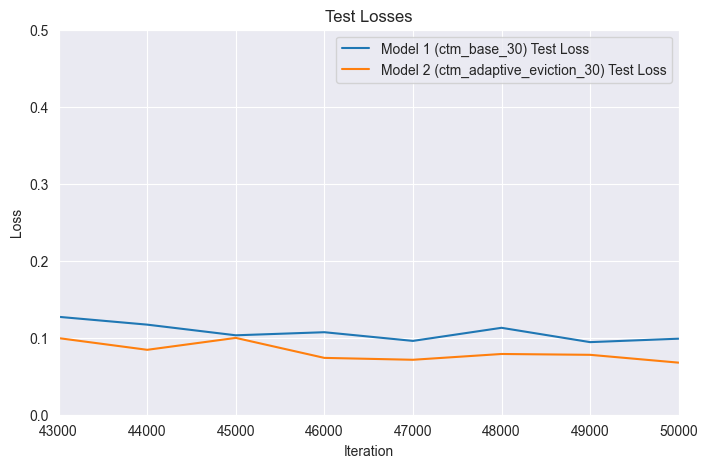

In [95]:
plt.figure(figsize=(8, 5))
for i, (iters, test_losses) in enumerate(zip(iters_lists, test_loss_lists)):
    label = f'Model {i+1} ({models[i][0]})'
    plt.plot(iters, test_losses, label=f'{label} Test Loss')

    
# Zoom to last 5000 iterations
plt.xlim(iters[-8], iters[-1])
plt.ylim(0, 0.5)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Test Losses')
plt.legend()

In [96]:
print(iters_lists[0])
print(iters_lists[1])

[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 46000, 47000, 48000, 49000, 50000]
[0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000, 11000, 12000, 13000, 14000, 15000, 16000, 17000, 18000, 19000, 20000, 21000, 22000, 23000, 24000, 25000, 26000, 27000, 28000, 29000, 30000, 31000, 32000, 33000, 34000, 35000, 36000, 37000, 38000, 39000, 40000, 41000, 42000, 43000, 44000, 45000, 46000, 47000, 48000, 49000, 50000]


In [97]:
[max(ac) for ac in test_accuracies_full_lists]

[0.3854166666666667, 0.5104166666666666]

In [98]:
[ac[-1] for ac in test_accuracies_full_lists]

[0.3229166666666667, 0.4583333333333333]